# Feline Age Group Classification — ML Baselines

Trains Logistic Regression and SVM classifiers on the YAMNet embeddings as baselines for comparison against the neural network approach in `feline_age_group_classif.ipynb`.

**Age groups:** Kitten (≤1 yr), Adult (1–10 yr), Senior (>10 yr)

**Data pipeline is kept identical to `feline_age_group_classif.ipynb`** (same split, scaler, PCA) so results are directly comparable.

## Download Dataset

In [1]:
import os
import shutil

In [2]:
def download_dataset(repo_url: str, dir_path_in_repo: str, output_dir_name: str):
    repo_name = repo_url.split('/')[-1].replace('.git', '')
    print(f"Cloning repository: {repo_url}...")
    !git clone --depth 1 {repo_url} {repo_name}
    source_path = os.path.join(repo_name, dir_path_in_repo)
    if os.path.exists(source_path):
        if os.path.exists(output_dir_name):
            shutil.rmtree(output_dir_name)
            print(f"Removed existing directory './{output_dir_name}'")
        shutil.copytree(source_path, output_dir_name)
        print(f"Successfully copied '{dir_path_in_repo}' to './{output_dir_name}'")
        shutil.rmtree(repo_name)
        print(f"Cleaned up cloned repository '{repo_name}'.")
    else:
        print(f"Error: Directory '{dir_path_in_repo}' not found in the cloned repository.")

In [3]:
DATASET_DIR = "feline_age_prediction_dataset"

download_dataset(
    "https://github.com/aster-droide/feline-age-prediction.git",
    os.path.join("dataset", "embeddings"),
    DATASET_DIR
)
print("\n--- Verify downloaded directories ---")
!ls -F

Cloning repository: https://github.com/aster-droide/feline-age-prediction.git...
Cloning into 'feline-age-prediction'...
remote: Enumerating objects: 3207, done.
remote: Counting objects: 100% (3207/3207), done.
remote: Compressing objects: 100% (2411/2411), done.
remote: Total 3207 (delta 1588), reused 2404 (delta 796), pack-reused 0 (from 0)
Receiving objects: 100% (3207/3207), 364.56 MiB | 15.94 MiB/s, done.
Resolving deltas: 100% (1588/1588), done.
Updating files: 100% (3199/3199), done.
Successfully copied 'dataset/embeddings' to './feline_age_prediction_dataset'
Cleaned up cloned repository 'feline-age-prediction'.

--- Verify downloaded directories ---
feline_age_prediction_dataset/	sample_data/


## Data Pre-processing

Identical pipeline to `feline_age_group_classif.ipynb` for fair comparison.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

AGE_GROUP_CATEGORIES = ['Kitten', 'Adult', 'Senior']
NUM_CLASSES = len(AGE_GROUP_CATEGORIES)
PCA_NUM_COMPONENTS = 32
RANDOM_SEEDS = [42, 7, 123]  # 3 seeds for mean/std reporting

In [5]:
def age_to_age_group(age: float) -> int:
    if age <= 1:
        return 0  # Kitten
    elif age <= 10:
        return 1  # Adult
    else:
        return 2  # Senior


def load_and_preprocess(random_state: int):
    """Load embeddings, label, split, scale, and PCA-reduce."""
    embeddings_path = os.path.join(DATASET_DIR, 'yamnet_looped_embeddings.csv')
    df = pd.read_csv(embeddings_path)

    # Rename target column and create age_group label
    df = df.rename(columns={'target': 'age'})
    df['age_group'] = df['age'].apply(age_to_age_group)

    # Keep only numeric embedding features + age_group
    df = df.drop(columns=[c for c in df.columns if c != 'age_group' and not c.isnumeric()])
    df = df.dropna()

    features = df.drop(columns='age_group')
    targets = df['age_group']

    # Train / temp split (80 / 20)
    X_train, X_temp, y_train, y_temp = train_test_split(
        features, targets, test_size=0.2, random_state=random_state,
        shuffle=True, stratify=targets
    )
    # Val / test split (50 / 50 of temp → 10 / 10 overall)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=random_state,
        shuffle=True, stratify=y_temp
    )

    # Standardize
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)

    # PCA
    pca = PCA(n_components=PCA_NUM_COMPONENTS, random_state=random_state)
    X_train = pca.fit_transform(X_train)
    X_val   = pca.transform(X_val)
    X_test  = pca.transform(X_test)

    return X_train, X_val, X_test, y_train.values, y_val.values, y_test.values


# Quick sanity check with first seed
X_train, X_val, X_test, y_train, y_val, y_test = load_and_preprocess(RANDOM_SEEDS[0])
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Class distribution (train): {dict(zip(*np.unique(y_train, return_counts=True)))}')

Train: (774, 32), Val: (97, 32), Test: (97, 32)
Class distribution (train): {np.int64(0): np.int64(198), np.int64(1): np.int64(408), np.int64(2): np.int64(168)}


## Evaluation Helpers

In [6]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt


def compute_metrics(y_true, y_pred) -> dict:
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }


def plot_confusion_matrix(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=AGE_GROUP_CATEGORIES)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## Multi-Seed Evaluation

Train each classifier across 3 random seeds and report mean ± std on the held-out test set.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


def build_classifiers(random_state: int) -> dict:
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, random_state=random_state
        ),
        'SVM (RBF)': SVC(
            kernel='rbf', C=1.0, gamma='scale', random_state=random_state
        ),
    }


# Collect per-seed metrics: {model_name: [metrics_dict, ...]}
seed_results: dict[str, list[dict]] = {}

for seed in RANDOM_SEEDS:
    X_train, X_val, X_test, y_train, y_val, y_test = load_and_preprocess(seed)
    classifiers = build_classifiers(seed)

    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        metrics = compute_metrics(y_test, y_pred)
        seed_results.setdefault(name, []).append(metrics)
        print(f'[seed={seed}] {name}: acc={metrics["accuracy"]:.3f}, macro-F1={metrics["f1"]:.3f}')

print('\nDone.')

[seed=42] Logistic Regression: acc=0.753, macro-F1=0.709
[seed=42] SVM (RBF): acc=0.670, macro-F1=0.527
[seed=7] Logistic Regression: acc=0.742, macro-F1=0.713
[seed=7] SVM (RBF): acc=0.691, macro-F1=0.596
[seed=123] Logistic Regression: acc=0.649, macro-F1=0.577
[seed=123] SVM (RBF): acc=0.660, macro-F1=0.497

Done.


In [8]:
# Aggregate mean ± std across seeds
summary_rows = []
for name, runs in seed_results.items():
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        vals = [r[metric] for r in runs]
        summary_rows.append({
            'Model': name,
            'Metric': metric,
            'Mean': np.mean(vals),
            'Std': np.std(vals),
            'Mean ± Std': f'{np.mean(vals):.3f} ± {np.std(vals):.3f}',
        })

summary_df = pd.DataFrame(summary_rows)
pivot = summary_df.pivot(index='Model', columns='Metric', values='Mean ± Std')
pivot = pivot[['accuracy', 'precision', 'recall', 'f1']]
pivot.columns = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
print('=== Multi-Seed Results (mean ± std over 3 seeds) ===')
print(pivot.to_string())

=== Multi-Seed Results (mean ± std over 3 seeds) ===
                          Accuracy Macro Precision   Macro Recall       Macro F1
Model                                                                           
Logistic Regression  0.715 ± 0.046   0.720 ± 0.086  0.657 ± 0.041  0.666 ± 0.063
SVM (RBF)            0.674 ± 0.013   0.649 ± 0.145  0.558 ± 0.018  0.540 ± 0.042


## Detailed Results on Seed 42

Full classification report and confusion matrices using the primary seed.


=== Logistic Regression ===
              precision    recall  f1-score   support

      Kitten       0.82      0.72      0.77        25
       Adult       0.72      0.90      0.80        51
      Senior       0.82      0.43      0.56        21

    accuracy                           0.75        97
   macro avg       0.79      0.68      0.71        97
weighted avg       0.77      0.75      0.74        97



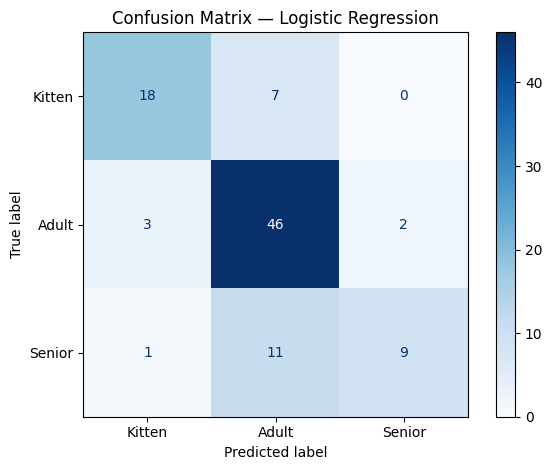


=== SVM (RBF) ===
              precision    recall  f1-score   support

      Kitten       0.89      0.64      0.74        25
       Adult       0.62      0.94      0.75        51
      Senior       0.50      0.05      0.09        21

    accuracy                           0.67        97
   macro avg       0.67      0.54      0.53        97
weighted avg       0.67      0.67      0.60        97



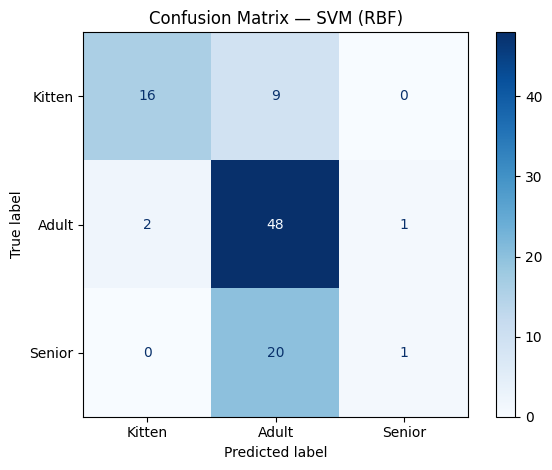

In [9]:
X_train, X_val, X_test, y_train, y_val, y_test = load_and_preprocess(42)

final_classifiers = build_classifiers(42)
for name, clf in final_classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=AGE_GROUP_CATEGORIES))
    plot_confusion_matrix(y_test, y_pred, f'Confusion Matrix — {name}')

## Hyperparameter Search for SVM

Quick grid search over `C` and `gamma` to find a stronger SVM baseline.

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV macro-F1: 0.638

Test set (best SVM):
              precision    recall  f1-score   support

      Kitten       0.72      0.72      0.72        25
       Adult       0.72      0.80      0.76        51
      Senior       0.67      0.48      0.56        21

    accuracy                           0.71        97
   macro avg       0.70      0.67      0.68        97
weighted avg       0.71      0.71      0.71        97



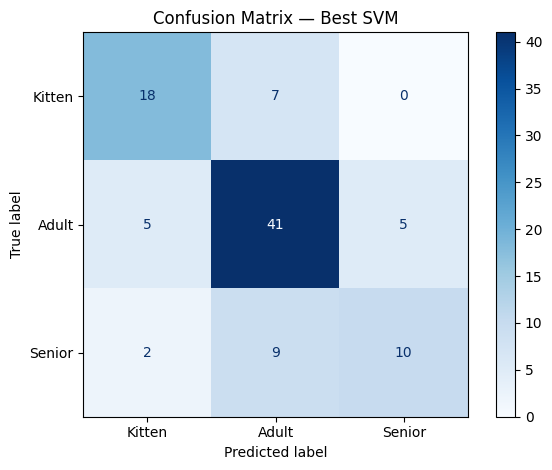

In [10]:
from sklearn.model_selection import GridSearchCV

X_train, X_val, X_test, y_train, y_val, y_test = load_and_preprocess(42)

param_grid = {
    'C':     [0.1, 1.0, 10.0],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'linear'],
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV macro-F1: {grid_search.best_score_:.3f}')

best_svm = grid_search.best_estimator_
y_pred_best = best_svm.predict(X_test)
print(f'\nTest set (best SVM):')
print(classification_report(y_test, y_pred_best, target_names=AGE_GROUP_CATEGORIES))
plot_confusion_matrix(y_test, y_pred_best, 'Confusion Matrix — Best SVM')

## Summary Table

Comparison including the neural network result from `feline_age_group_classif.ipynb` (seed 42).

In [11]:
# Neural net result from feline_age_group_classif.ipynb (seed 42, best model)
nn_result = {
    'Model': 'Neural Net (Adam + BatchNorm + L2)',
    'Accuracy': '0.763',
    'Macro Precision': '0.77',
    'Macro Recall': '0.73',
    'Macro F1': '0.74',
    'Note': 'from feline_age_group_classif.ipynb'
}

rows = []
for name, clf in final_classifiers.items():
    y_pred = clf.predict(X_test)
    m = compute_metrics(y_test, y_pred)
    rows.append({
        'Model': name,
        'Accuracy': f'{m["accuracy"]:.3f}',
        'Macro Precision': f'{m["precision"]:.3f}',
        'Macro Recall': f'{m["recall"]:.3f}',
        'Macro F1': f'{m["f1"]:.3f}',
        'Note': 'seed 42'
    })

y_pred_best = best_svm.predict(X_test)
m = compute_metrics(y_test, y_pred_best)
rows.append({
    'Model': 'SVM (best params)',
    'Accuracy': f'{m["accuracy"]:.3f}',
    'Macro Precision': f'{m["precision"]:.3f}',
    'Macro Recall': f'{m["recall"]:.3f}',
    'Macro F1': f'{m["f1"]:.3f}',
    'Note': 'grid search, seed 42'
})

rows.append(nn_result)

comparison_df = pd.DataFrame(rows)
print('=== Model Comparison (seed 42 test set) ===')
print(comparison_df.to_string(index=False))

=== Model Comparison (seed 42 test set) ===
                             Model Accuracy Macro Precision Macro Recall Macro F1                                Note
               Logistic Regression    0.753           0.785        0.684    0.709                             seed 42
                         SVM (RBF)    0.670           0.671        0.543    0.527                             seed 42
                 SVM (best params)    0.711           0.702        0.667    0.678                grid search, seed 42
Neural Net (Adam + BatchNorm + L2)    0.763            0.77         0.73     0.74 from feline_age_group_classif.ipynb
